# Learning-CBF analysis

Iterative pipeline for inspecting how dataset structure drives CBF performance.

1. **Overview** — all runs (any method), Pareto front over (violations, runtime, ‖θ‖).
2. **Selection** — pick one run (default: smallest-violation point on the Pareto front).
3. **Dataset diagnostics** — density / coverage of the dataset the selected run was trained on.
4. **Run inspector** — config, metrics, level-set plot, verification bars.
5. **Distribution ↔ performance** — cross-run scatter of dataset stats against violations.

Method-agnostic: when NN runs are added under `runs/cbfs/nn/`, they join the overview automatically.

In [62]:
# --- imports + shared helpers -----------------------------------------
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.spatial import cKDTree

REPO = Path.cwd()
sys.path.append(str(REPO))
import pipeline_io as pio

METHODS    = ("rff", "nn")          # extend as new learners arrive
VIOL_W     = dict(safe=1.0, unsafe=1.0, dyn=0.5)

# ----- RFF feature maps (only one currently in use) -------------------
def _phi_rff(x, W, b):
    L = W.shape[0]
    return np.sqrt(2.0 / L) * np.cos(x @ W.T + b)

def _dphi_rff(x, W, b):
    L = W.shape[0]
    z = x @ W.T + b
    return -np.sqrt(2.0 / L) * np.sin(z)[:, :, None] * W[None, :, :]

def load_model_fn(run_dir, method):
    """Return (h, grad_h) callables for the model stored in run_dir."""
    if method == "rff":
        m = np.load(run_dir / "model.npz")
        th, W, b = m["theta"], m["W"], m["b"]
        h     = lambda x: _phi_rff(x, W, b) @ th
        grad  = lambda x: np.einsum("ilk,l->ik", _dphi_rff(x, W, b), th)
        return h, grad
    raise NotImplementedError(f"method={method!r} not wired into load_model_fn yet")

def load_dataset(ds_tag):
    d = pio.resolve_existing(pio.STAGE_DATA, ds_tag)
    safe   = pd.read_csv(d / "safe.csv").to_numpy()
    unsafe = pd.read_csv(d / "unsafe.csv").to_numpy()
    expert = pd.read_csv(d / "expert_safe.csv")
    return dict(dir=d, safe=safe, unsafe=unsafe,
                X_exp=expert[["x","y","theta"]].to_numpy(),
                U_exp=expert[["v","omega"]].to_numpy())

def compute_violations(run_dir, method, cfg, ds):
    """Cached per run — stored as verification.json beside config.json."""
    cache = run_dir / "verification.json"
    if cache.exists():
        return json.loads(cache.read_text())
    h, grad = load_model_fn(run_dir, method)
    gs, gu, gd = cfg["gamma_safe"], cfg["gamma_unsafe"], cfg["gamma_dyn"]
    h_s, h_u = h(ds["safe"]), h(ds["unsafe"])
    h_e      = h(ds["X_exp"])
    v_e, om_e, th_e = ds["U_exp"][:,0], ds["U_exp"][:,1], ds["X_exp"][:,2]
    xdot = np.column_stack([v_e*np.cos(th_e), v_e*np.sin(th_e), om_e])
    q    = (grad(ds["X_exp"]) * xdot).sum(axis=1) + h_e
    out = dict(
        safe   = 100.0 * float((h_s   - gs < 0).mean()),
        unsafe = 100.0 * float((-h_u  - gu < 0).mean()),
        dyn    = 100.0 * float((q     - gd < 0).mean()),
    )
    out["total"] = (VIOL_W["safe"]*out["safe"] + VIOL_W["unsafe"]*out["unsafe"]
                    + VIOL_W["dyn"]*out["dyn"])
    cache.write_text(json.dumps(out, indent=2))
    return out

def pareto_mask(points):
    """Boolean mask of non-dominated rows (lower is better on every column)."""
    P = np.asarray(points, dtype=float)
    n = len(P)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]: continue
        dominated = np.all(P <= P[i], axis=1) & np.any(P < P[i], axis=1)
        dominated[i] = False
        if dominated.any(): keep[i] = False
    return keep

print("helpers ready.")

helpers ready.


## 1. Run overview — leaderboard + Pareto front

In [71]:
# --- load every run, compute (cached) violations, mark Pareto front ----
idx_p = pio.RUNS_DIR / "cbfs" / "index.csv"
if not idx_p.exists():
    raise FileNotFoundError(f"No CBF index at {idx_p}")
idx_all = pd.read_csv(idx_p)
idx_all = idx_all[idx_all["method"].isin(METHODS)].copy()

rows = []
for _, r in idx_all.iterrows():
    method = r["method"]
    try:
        rd  = pio.resolve_existing(pio.STAGE_CBF, r["tag"], method=method)
        cfg = json.loads((rd / "config.json").read_text())
        met = json.loads((rd / "metrics.json").read_text())
    except Exception as e:
        print(f"  ! skip {method}/{r['tag']}: {e}")
        continue
    try:
        v = compute_violations(rd, method, cfg, load_dataset(r["dataset_tag"]))
    except Exception as e:
        v = dict(safe=np.nan, unsafe=np.nan, dyn=np.nan, total=np.nan)
        print(f"  ! viol {r['tag']}: {e}")
    rows.append(dict(
        method=method, tag=r["tag"], dataset=r["dataset_tag"],
        n_features=cfg.get("n_features"), sigma=cfg.get("sigma"),
        theta_norm=met.get("theta_norm"), runtime_s=met.get("runtime_s"),
        v_safe=v["safe"], v_unsafe=v["unsafe"], v_dyn=v["dyn"],
        v_total=v["total"], _ts=r["_ts"],
    ))

if not rows:
    raise RuntimeError(f"Index has {len(idx_all)} rows but no runs loaded.")

runs = pd.DataFrame(rows).sort_values("_ts").reset_index(drop=True)
P = runs[["v_total", "runtime_s", "theta_norm"]].to_numpy()
runs["pareto"] = pareto_mask(np.nan_to_num(P, nan=np.inf))

show_cols = ["pareto","method","tag","n_features","sigma",
             "v_safe","v_unsafe","v_dyn","v_total",
             "theta_norm","runtime_s","dataset"]
print(f"{len(runs)} runs across methods={list(runs['method'].unique())}")
print(f"Pareto-optimal: {int(runs['pareto'].sum())} on (v_total, runtime_s, theta_norm)\n")
with pd.option_context("display.max_colwidth", 60, "display.width", 220):
    print(runs.sort_values("v_total")[show_cols].to_string(index=False))

11 runs across methods=['rff']
Pareto-optimal: 2 on (v_total, runtime_s, theta_norm)

 pareto method                            tag  n_features  sigma    v_safe  v_unsafe    v_dyn   v_total  theta_norm  runtime_s                                                       dataset
   True    rff soft_L400_sig1.5_gs1.5__082ec5         400    1.5  0.933333  0.200000 4.298643  3.282655   42.170124  29.143649        sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c
   True    rff soft_L400_sig1.5_gs1.5__1937de         400    1.5  0.800000  0.066667 5.717620  3.725476   37.088493  18.082377        sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000__6f59c8
  False    rff soft_L400_sig1.3_gs1.5__3277a5         400    1.3  0.975000  0.266667 4.977376  3.730354   48.087753  49.614728 sig0.10_marg1.2_n4000_synU3000_bboxOv_subE5000_neu600__2627ee
  False    rff soft_L400_sig1.5_gs1.5__c239a0         400    1.5  3.400000  2.633333 3.511876  7.789271  132.792604 448.776849                 sig0.10_marg1.5

### How to read these numbers

| metric | what it counts | green | yellow | red |
|---|---|---|---|---|
| `v_safe` | % of safe points where `h(x) < γ_safe` — CBF too pessimistic, shrinks the safe set | < 1 % | 1–5 % | > 5 % |
| `v_unsafe` | % of unsafe points where `-h(x) < γ_unsafe` — CBF leaks; safety failure | < 0.5 % | 0.5–2 % | > 2 % |
| `v_dyn` | % of expert pairs where `⟨∇h, ẋ⟩ + h < γ_dyn` — controller can't keep h growing fast enough | < 2 % | 2–10 % | > 10 % |
| `v_total` | `v_safe + v_unsafe + 0.5·v_dyn` — single score for sorting / Pareto | — | — | — |
| `‖θ‖` | RFF weight magnitude. Big = sharper, less regularized → can overfit and inflate `v_dyn` | — | — | — |

Reading the rows: `unsafe` failures are the only hard safety concern — `safe` and `dyn` trade against each other (looser γ_dyn → fewer dyn violations but a tighter safe set). When `unsafe ≈ 0` everywhere, sort by `v_dyn` and look at what changed in the dataset (next section).

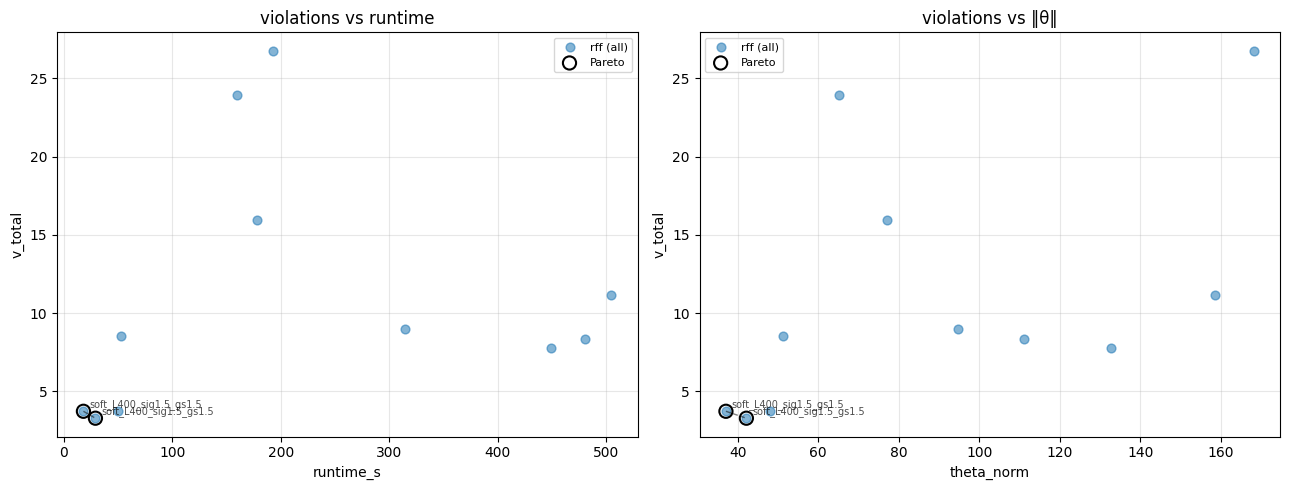

In [72]:
# --- Pareto scatter: violations vs runtime, sized by ||theta|| ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (xc, yc) in zip(axes, [("runtime_s", "v_total"),
                                ("theta_norm", "v_total")]):
    for m, sub in runs.groupby("method"):
        ax.scatter(sub[xc], sub[yc], s=40, alpha=0.55, label=f"{m} (all)")
    front = runs[runs["pareto"]].sort_values(xc)
    ax.plot(front[xc], front[yc], "k--", lw=1, alpha=0.5)
    ax.scatter(front[xc], front[yc], s=90,
               facecolors="none", edgecolors="k", lw=1.5, label="Pareto")
    for _, r in front.iterrows():
        ax.annotate(r["tag"].split("__")[0], (r[xc], r[yc]),
                    fontsize=7, alpha=0.7, xytext=(4,3), textcoords="offset points")
    ax.set_xlabel(xc); ax.set_ylabel(yc); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_title("violations vs runtime")
axes[1].set_title("violations vs ‖θ‖")
plt.tight_layout(); plt.show()

## 2. Selection

`TAG = None` picks the Pareto-front run with the lowest total violation — a neutral default. Override `TAG` to inspect any other run.

In [81]:
TAG    = None         # e.g. "soft_L400_sig1.3_gs1.5__3277a5"
METHOD = "rff"
THETA_SLICE_DEG = 45
GRID_N = 140

if TAG is None:
    front = runs[(runs["method"] == METHOD) & runs["pareto"]].sort_values("v_total")
    TAG = front.iloc[0]["tag"]
    print(f"auto-picked Pareto run with min v_total: {TAG}")

sel = runs[(runs["method"] == METHOD) & (runs["tag"] == TAG)].iloc[0]
run_dir = Path(pio.resolve_existing(pio.STAGE_CBF, TAG, method=METHOD))
cfg = json.loads((run_dir / "config.json").read_text())
met = json.loads((run_dir / "metrics.json").read_text())
ds  = load_dataset(cfg["dataset_tag"])

print(f"\n== run     {TAG}    ({METHOD})")
print(f"   pareto  {bool(sel['pareto'])}")
print(f"== dataset {cfg['dataset_tag']}")
print(f"   safe {ds['safe'].shape[0]:>6d}   unsafe {ds['unsafe'].shape[0]:>6d}"
      f"   expert {ds['X_exp'].shape[0]:>6d}")

auto-picked Pareto run with min v_total: soft_L400_sig1.5_gs1.5__082ec5

== run     soft_L400_sig1.5_gs1.5__082ec5    (rff)
   pareto  True
== dataset sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c
   safe   1500   unsafe   3000   expert   2210


## 3. Dataset diagnostics for the selected run

Mirrors `expert_data_generation/set-analyisis.ipynb`: density, heading coverage, boundary sampling. Same numbers we'll regress against violations in section 5.

In [82]:
def dataset_metrics(ds, obs, sigma_band=0.15, theta_w=0.5, k=5,
                    nx=40, ny=40, n_theta_bins=12):
    """Single source of truth for dataset stats — used here and in section 5."""
    X_exp, X_safe, X_uns = ds["X_exp"], ds["safe"], ds["unsafe"]
    X = np.vstack([X_exp, X_safe, X_uns])
    lbl = np.concatenate([np.zeros(len(X_exp), int),
                          np.ones (len(X_safe), int),
                          np.full (len(X_uns),  2, int)])
    emb = np.column_stack([X[:,0], X[:,1],
                           theta_w*np.cos(X[:,2]), theta_w*np.sin(X[:,2])])
    knn = cKDTree(emb).query(emb, k=k+1)[0][:, -1]
    xmin,xmax = X[:,0].min(), X[:,0].max()
    ymin,ymax = X[:,1].min(), X[:,1].max()
    H_xy, xe, ye = np.histogram2d(X[:,0], X[:,1], bins=[nx,ny],
                                  range=[[xmin,xmax],[ymin,ymax]])
    p = H_xy / H_xy.sum(); pnz = p[p>0]
    occupied = (H_xy > 0).mean()
    entropy_frac = -(pnz*np.log(pnz)).sum() / np.log(H_xy.size)
    # heading coverage on expert_safe
    tb = np.floor((X_exp[:,2] % (2*np.pi)) / (2*np.pi) * n_theta_bins).astype(int)
    xb = np.clip(np.searchsorted(xe, X_exp[:,0], side="right")-1, 0, nx-1)
    yb = np.clip(np.searchsorted(ye, X_exp[:,1], side="right")-1, 0, ny-1)
    seen = {}
    for xi, yi, ti in zip(xb, yb, tb):
        seen.setdefault((xi,yi), set()).add(ti)
    head_per_cell = np.array([len(s) for s in seen.values()]) if seen else np.array([0])
    # boundary band density on the safe side
    cx, cy, r = obs
    r_band = r + 0.1
    def _band(arr, lo, hi):
        d = np.hypot(arr[:,0]-cx, arr[:,1]-cy); return int(((d>lo)&(d<=hi)).sum())
    near = _band(X_exp, r_band, r_band+sigma_band) + _band(X_safe, r_band, r_band+sigma_band)
    bdy_ratio = near / max(len(X_uns), 1)
    return dict(
        n_safe=len(X_safe), n_unsafe=len(X_uns), n_expert=len(X_exp),
        knn_p95=float(np.quantile(knn, 0.95)),
        knn_median=float(np.median(knn)),
        xy_occupancy=float(occupied),
        xy_entropy_frac=float(entropy_frac),
        heading_mean=float(head_per_cell.mean()),
        boundary_safe_ratio=float(bdy_ratio),
        _knn=knn, _lbl=lbl, _X=X, _H_xy=H_xy,
        _bbox=(xmin,xmax,ymin,ymax),
    )

OBS = (cfg.get("obstacle",{}).get("x",2.0),
       cfg.get("obstacle",{}).get("y",2.0),
       cfg.get("obstacle",{}).get("radius",0.5))
# obstacle may live on the dataset config instead
ds_cfg = json.loads((ds["dir"]/"config.json").read_text())
OBS = (ds_cfg["obstacle"]["x"], ds_cfg["obstacle"]["y"], ds_cfg["obstacle"]["radius"])

dm = dataset_metrics(ds, OBS)
scalar = {k:v for k,v in dm.items() if not k.startswith("_")}
for k,v in scalar.items():
    print(f"  {k:22s} {v:.4f}" if isinstance(v, float) else f"  {k:22s} {v}")

  n_safe                 1500
  n_unsafe               3000
  n_expert               2210
  knn_p95                0.4509
  knn_median             0.1293
  xy_occupancy           0.8494
  xy_entropy_frac        0.8292
  heading_mean           1.5514
  boundary_safe_ratio    0.0293


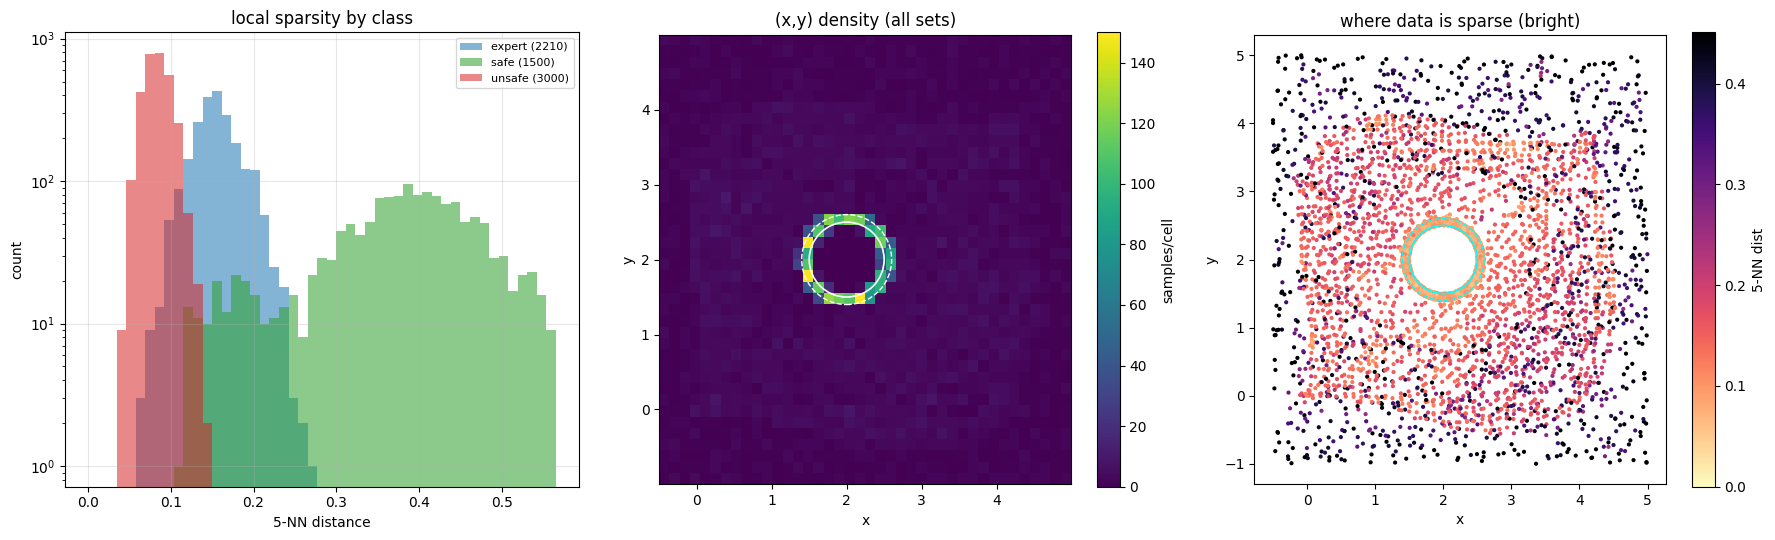

In [83]:
# --- dataset visuals: kNN per class, (x,y) density, sparsity map -------
knn, lbl, X, H_xy = dm["_knn"], dm["_lbl"], dm["_X"], dm["_H_xy"]
xmin,xmax,ymin,ymax = dm["_bbox"]; cx,cy,r = OBS

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
bins = np.linspace(0, np.quantile(knn, 0.995), 50)
for k_lbl, name, color in [(0,"expert","tab:blue"),(1,"safe","tab:green"),(2,"unsafe","tab:red")]:
    ax.hist(knn[lbl==k_lbl], bins=bins, alpha=0.55, color=color,
            label=f"{name} ({(lbl==k_lbl).sum()})")
ax.set_yscale("log"); ax.set_xlabel("5-NN distance"); ax.set_ylabel("count")
ax.set_title("local sparsity by class"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
im = ax.imshow(H_xy.T, origin="lower", extent=[xmin,xmax,ymin,ymax],
               cmap="viridis", aspect="equal")
ax.add_patch(Circle((cx,cy), r, facecolor="none", edgecolor="w", lw=1.2))
ax.add_patch(Circle((cx,cy), r+0.1, facecolor="none", edgecolor="w", lw=1, ls="--"))
plt.colorbar(im, ax=ax, label="samples/cell")
ax.set_title("(x,y) density (all sets)"); ax.set_xlabel("x"); ax.set_ylabel("y")

ax = axes[2]
rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=min(6000, len(X)), replace=False)
sc = ax.scatter(X[idx,0], X[idx,1], c=knn[idx], s=4, cmap="magma_r",
                vmin=0, vmax=np.quantile(knn, 0.95))
plt.colorbar(sc, ax=ax, label="5-NN dist")
ax.add_patch(Circle((cx,cy), r, facecolor="none", edgecolor="cyan", lw=1.2))
ax.add_patch(Circle((cx,cy), r+0.1, facecolor="none", edgecolor="cyan", lw=1, ls="--"))
ax.set_aspect("equal"); ax.set_title("where data is sparse (bright)")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. Run inspector — verification + level set

violations  safe=0.93%  unsafe=0.20%  dyn=4.30%   total=3.28


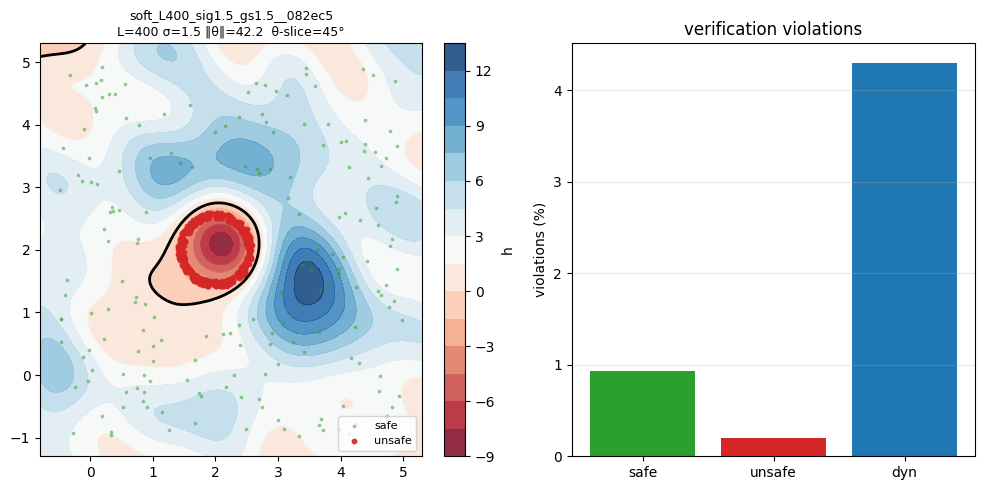

In [84]:
h_fn, grad_fn = load_model_fn(run_dir, METHOD)
viol = compute_violations(run_dir, METHOD, cfg, ds)
print(f"violations  safe={viol['safe']:.2f}%  unsafe={viol['unsafe']:.2f}%  dyn={viol['dyn']:.2f}%"
      f"   total={viol['total']:.2f}")

th_slice = np.deg2rad(THETA_SLICE_DEG)
all_xy = np.vstack([ds["safe"][:,:2], ds["unsafe"][:,:2], ds["X_exp"][:,:2]])
xmin, ymin = all_xy.min(0) - 0.3; xmax, ymax = all_xy.max(0) + 0.3
XX, YY = np.meshgrid(np.linspace(xmin,xmax,GRID_N), np.linspace(ymin,ymax,GRID_N))
pts = np.column_stack([XX.ravel(), YY.ravel(), np.full(XX.size, th_slice)])
H = h_fn(pts).reshape(XX.shape)

def _near(arr, th):
    dth = np.abs(((arr[:,2] - th + np.pi) % (2*np.pi)) - np.pi)
    return arr[dth < np.pi/8]

fig = plt.figure(figsize=(11, 5))
gs_ = fig.add_gridspec(1, 2, width_ratios=[1.4, 1])
ax = fig.add_subplot(gs_[0,0])
cf = ax.contourf(XX, YY, H, levels=20, cmap="RdBu", alpha=0.85)
ax.contour(XX, YY, H, levels=[0.0], colors="k", linewidths=2.0)
plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label="h")
s_ = _near(ds["safe"], th_slice); u_ = _near(ds["unsafe"], th_slice)
if len(s_): ax.scatter(s_[:,0], s_[:,1], s=3,  c="tab:green", alpha=0.4, label="safe")
if len(u_): ax.scatter(u_[:,0], u_[:,1], s=10, c="tab:red",   alpha=0.9, label="unsafe")
ax.set_aspect("equal"); ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax)
ax.set_title(f"{TAG}\nL={cfg.get('n_features')} σ={cfg.get('sigma')} "
             f"‖θ‖={met.get('theta_norm',0):.1f}  θ-slice={THETA_SLICE_DEG}°", fontsize=9)
ax.legend(loc="lower right", fontsize=8)

ax = fig.add_subplot(gs_[0,1])
ax.bar(["safe","unsafe","dyn"], [viol["safe"], viol["unsafe"], viol["dyn"]],
       color=["tab:green","tab:red","tab:blue"])
ax.set_ylabel("violations (%)"); ax.grid(alpha=0.3, axis="y")
ax.set_title("verification violations")
plt.tight_layout(); plt.show()

## 5. Distribution ↔ performance

Annotate every run with its dataset metrics, then scatter against violation rates. Tells us which data-distribution knob the next run should tune.

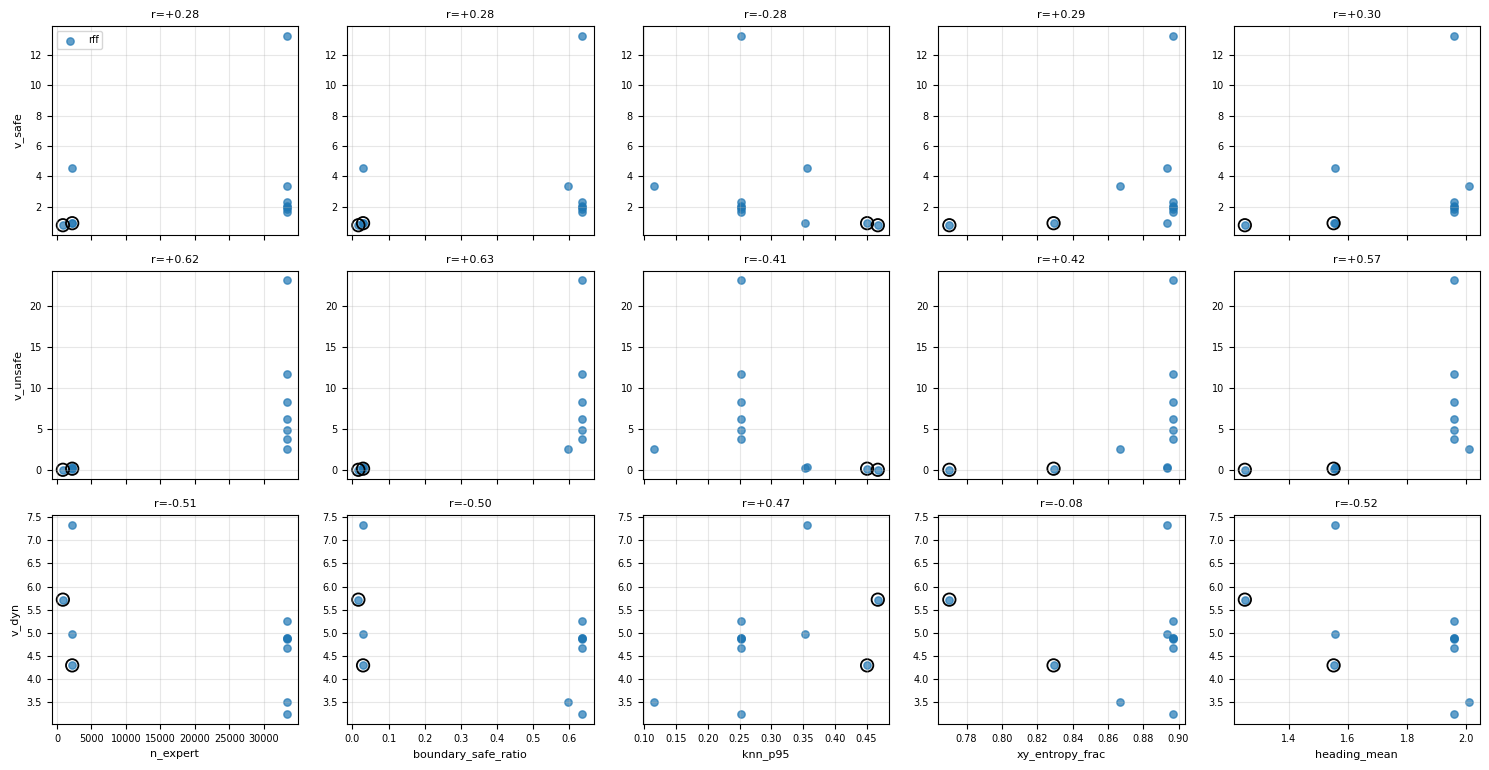


linked table (sorted by v_total):
method                            tag   v_total    v_safe  v_unsafe    v_dyn  n_expert  boundary_safe_ratio  knn_p95  xy_entropy_frac  heading_mean  pareto
   rff soft_L400_sig1.5_gs1.5__082ec5  3.282655  0.933333  0.200000 4.298643      2210             0.029333 0.450865         0.829244      1.551445    True
   rff soft_L400_sig1.5_gs1.5__1937de  3.725476  0.800000  0.066667 5.717620       857             0.016333 0.467762         0.770247      1.251300    True
   rff soft_L400_sig1.3_gs1.5__3277a5  3.730354  0.975000  0.266667 4.977376      2210             0.029333 0.353760         0.893521      1.555556   False
   rff soft_L400_sig1.5_gs1.5__c239a0  7.789271  3.400000  2.633333 3.511876     33344             0.597000 0.114790         0.866870      2.008584   False
   rff soft_L400_sig1.5_gs1.5__f87152  8.374126  2.066667  3.870739 4.873440     33344             0.636009 0.252635         0.897029      1.957391   False
   rff soft_L400_sig0.8_gs1.5

In [85]:
# --- compute (and cache) dataset metrics for each unique dataset -------
_DS_CACHE = {}
def _ds_scalar(tag):
    if tag in _DS_CACHE: return _DS_CACHE[tag]
    d = load_dataset(tag)
    c = json.loads((d["dir"]/"config.json").read_text())
    obs = (c["obstacle"]["x"], c["obstacle"]["y"], c["obstacle"]["radius"])
    m = dataset_metrics(d, obs)
    s = {k:v for k,v in m.items() if not k.startswith("_")}
    _DS_CACHE[tag] = s
    return s

ds_stats = pd.DataFrame([_ds_scalar(t) for t in runs["dataset"]])
linked = pd.concat([runs.reset_index(drop=True), ds_stats], axis=1)

X_FIELDS = ["n_expert", "boundary_safe_ratio", "knn_p95",
            "xy_entropy_frac", "heading_mean"]
Y_FIELDS = ["v_safe", "v_unsafe", "v_dyn"]

fig, axes = plt.subplots(len(Y_FIELDS), len(X_FIELDS),
                         figsize=(3.0*len(X_FIELDS), 2.6*len(Y_FIELDS)),
                         sharex="col")
for i, yc in enumerate(Y_FIELDS):
    for j, xc in enumerate(X_FIELDS):
        ax = axes[i, j]
        for m, sub in linked.groupby("method"):
            ax.scatter(sub[xc], sub[yc], s=28, alpha=0.7, label=m)
        front = linked[linked["pareto"]]
        ax.scatter(front[xc], front[yc], s=80, facecolors="none",
                   edgecolors="k", lw=1.3)
        # correlation annotation (Pearson, drop NaNs)
        sub2 = linked[[xc, yc]].dropna()
        if len(sub2) >= 3:
            r = np.corrcoef(sub2[xc], sub2[yc])[0,1]
            ax.set_title(f"r={r:+.2f}", fontsize=8)
        if i == len(Y_FIELDS)-1: ax.set_xlabel(xc, fontsize=8)
        if j == 0:               ax.set_ylabel(yc, fontsize=8)
        ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
axes[0,0].legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()

print("\nlinked table (sorted by v_total):")
with pd.option_context("display.max_colwidth", 50, "display.width", 220):
    cols = ["method","tag","v_total","v_safe","v_unsafe","v_dyn",
            "n_expert","boundary_safe_ratio","knn_p95",
            "xy_entropy_frac","heading_mean","pareto"]
    print(linked.sort_values("v_total")[cols].to_string(index=False))